**ARBRES de DECISIONS**

https://scikit-learn.org/stable/modules/tree.html

L'Arbre de Décision permet de  de classifier des données en se basant sur des suites de conditions.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from sklearn import tree  #méthode
X = [[0, 0], [1, 1]]
y = [0, 1]
clf = tree.DecisionTreeClassifier() #objet d'apprentissage
clf = clf.fit(X, y)    #apprentissage
estimation = clf.predict([[2,2]])
print(estimation)

[1]


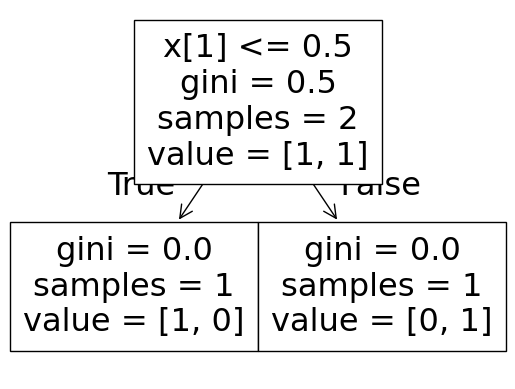

In [3]:
tree.plot_tree(clf)
plt.show()

In [4]:
#Importer Iris dataset
from sklearn.datasets import load_iris
#Importer module Arbre de Décision
from sklearn import tree

iris = load_iris()
X, y = iris.data, iris.target

#Définir modèle comme Arbre de Décision de profondeur 2
model= tree.DecisionTreeClassifier(max_depth=2)

#Apprentissage
model_l = model.fit(X, y)

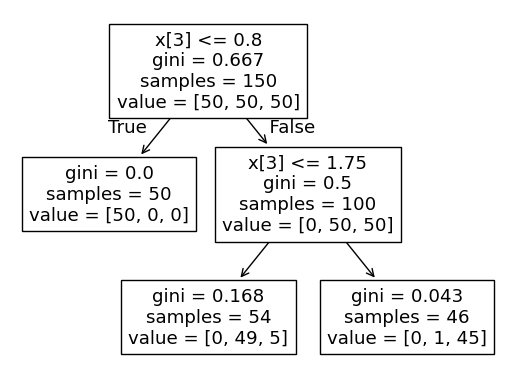

In [5]:
# visualisez après l'apprentissage
tree.plot_tree(model_l)
plt.show()

* Il commence avec la condition que son algorithme trouve plus pertinent et crée trois sous-groupes (3 étiquettes)

    *La décision à la racine X[3] <=0.8
    
    * gini :mesure de "pureté de décision" 
        * gini=0 -> les données (samples) du noeud ont la même étiquette
        * gini >0 -> les données du noeud ont d'étiquettes différentes
        * les valeurs proches de 0 sont meilleures (si 0, discrimination parfaite de données)
    
    * samples : le nombre de données de  ce noeud
    
    * value : nombres de données versus étiquette
        * [50,50,50] -> il y 50 données avec étiquette 0; 50 avec étiquette 1, 50 avec étiquette 2
        
*  aller à gauche si la réponse est fausse, sinon à droite

* max_depth est paramètre qui doit être précisé

* Appliquer d'une façon récursive à chaque noeud jusq'au soit gini =0 ou max-depth n'est pas atteinte




In [6]:
#sepal_length=5.6; sepal_width=6.1; petal_length=1; petal_width=1.2
#0 :Setosa; 1:Versicolour; 2:Virginica

Xnew =[[5.6, 6.1, 1, 1.2 ]]



print(model_l.predict(Xnew))

#X[3] >0.8  aller à droite
# X[3] <= 1.75  aller à gauche
#plus probable que c'est 1




[1]


In [7]:
#sepal_length=5; sepal_width=4; petal_length=0.75; petal_width=1.8
#0 :Setosa; 1:Versicolour; 2:Virginica

Xnew =[[5,4,0.75,1.8 ]]



print(model_l.predict(Xnew))

#X[3] >0.8 et X[3] >1.75   plus de probable que ca soit classe 2



[2]


In [8]:
#sepal_length=5; sepal_width=4; petal_length=1.75; petal_width=0.75
#0 :Setosa; 1:Versicolour; 2:Virginica

Xnew =[[5,4,1.75,0.75 ]]



print(model_l.predict(Xnew))

#X[3] <=0.8  donc classe 0



[0]


Lisez  la partie chemin de décision pour mieux comprendre 

https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py

In [9]:
#Visualisez  avec les noms d'attributs

from sklearn.tree import export_text
r = export_text(model_l, feature_names=iris['feature_names'])
print(r)

#Dessinez sous forme d'arbre de décision

|--- petal width (cm) <= 0.80
|   |--- class: 0
|--- petal width (cm) >  0.80
|   |--- petal width (cm) <= 1.75
|   |   |--- class: 1
|   |--- petal width (cm) >  1.75
|   |   |--- class: 2



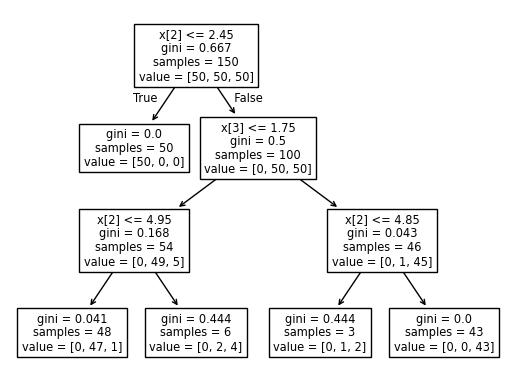

array([[50,  0,  0],
       [ 0, 47,  1],
       [ 0,  3, 49]])

In [10]:
#Dessinez l'Arbre de Décision de profondeur 3 
#D'abord avec plot_tree
#Puis avec export_text

model= tree.DecisionTreeClassifier(max_depth=3)
model_l = model.fit(X, y)
tree.plot_tree(model_l)
plt.show()

from sklearn.metrics import confusion_matrix

y_pred=model_l.predict(X)

confusion_matrix(y_pred,y)

In [11]:
r = export_text(model_l, feature_names=iris['feature_names'])
print(r)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: 1
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



In [12]:

#sepal_length=5.6; sepal_width=6.1; petal_length=1; petal_width=1.2
#0 :Setosa; 1:Versicolour; 2:Virginica

Xnew =[[5.6, 6.1, 1, 1.2 ]]

#Vous suivez d'abord l'AD pour trouver la réponse puis confirmer 
#le résultat par le logiciel
print(model_l.predict(Xnew))

[0]


In [13]:
#sepal_length=5; sepal_width=4; petal_length=0.75; petal_width=1.8
#0 :Setosa; 1:Versicolour; 2:Virginica

Xnew =[[5,4,0.75,1.8 ]]



print(model_l.predict(Xnew))

[0]


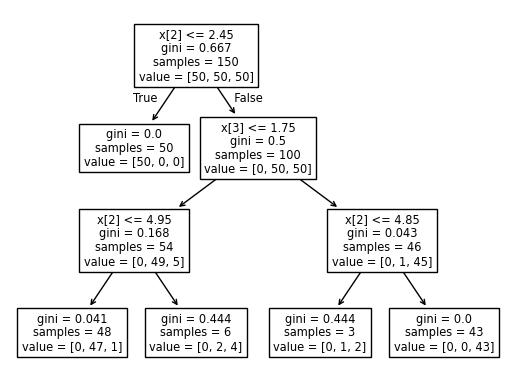

In [20]:
model= tree.DecisionTreeClassifier(max_depth=3)
model_l = model.fit(X, y)
tree.plot_tree(model_l)
plt.show()

In [15]:
Xnew =[[5,6.1,2.6,1.8 ]]
print(model_l.predict(Xnew))

[1]


In [16]:
r = export_text(model_l, feature_names=iris['feature_names'])
print(r)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- class: 1



In [17]:
model_l.score(X,y)

0.6666666666666666